Sept 2023, Alekh, Sept 2025, Sixuan, Sept 2026, Peisen

This notebook is partly based on *Introduction to Linear Algebra* by Gilbert Strang.


# **CPSY 1291 Fall25**
## **Recitation 2**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

def plot_vector(vectors):
  """
  Plot vectors in a 2D space.

  Params
  ----------
  vectors: list or array-like
    A list or array of 2D vectors to be plotted
  """
  vectors = np.array(vectors)
  if vectors.ndim==1:
    vectors = vectors[np.newaxis, :]
  vecs = np.stack(vectors)
  origin = np.zeros((2, vecs.shape[0])) # origin point
  plt.figure()
  plt.quiver(*origin, vecs[:,0], vecs[:,1], color=['r','b','g','c','m',
                                                   'y','k','w'], angles='xy', scale_units='xy', scale=1)
  plt.axis('square')
  plt.axhline(0, color='black', linewidth=.5)
  plt.axvline(0, color='black', linewidth=.5)
  plt.xlim(-4, 4)
  plt.ylim(-4, 4)
  plt.grid()

### **What is a vector**

A vector is an ordered collection of numbers, known as the components of the vector:

\begin{align}
  \vec{v} = \begin{bmatrix}
           v_{1} \\
           v_{2} \\
           \vdots \\
           v_{N}
         \end{bmatrix}
  \\
  \\
  \vec{v_1} = \begin{bmatrix}
           1 \\
           2 \\
         \end{bmatrix} \\
         \\
    \vec{v_2} = \begin{bmatrix}
           -1 \\
           3 \\
         \end{bmatrix}
\end{align}

* A vector can be considered a point or a direction.
* One feature is one elment of a vector. A list of features form a datapoint.

**Norm** of a vector:
 $$\lVert \vec{v} \rVert = \sqrt{v^2_1 + v^2_2 + v^2_3 + .... +v^2_N } $$

* This gives the magnitude of the vector. In two dimensions, it is easy to see that this is the Pythagorean theorem.





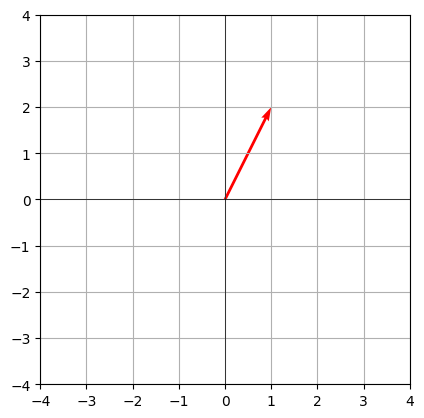

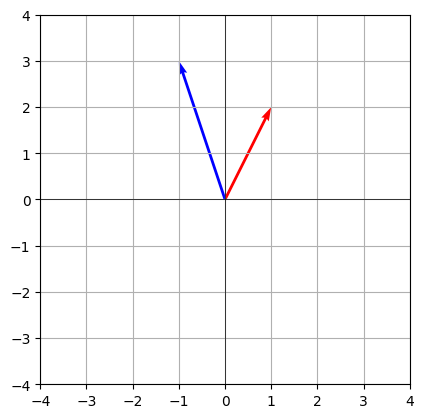

In [2]:
v1 = np.array([1, 2])
plot_vector(v1)


v2 = np.array([-1, 3])
plot_vector([v1, v2])


### **Linear Combination of Vectors**

* We can multiply vectors with numbers and add two vectors together.
* All linear combinations of two independent vectors fill (**span**) a plane.

**Scalar multiplication**
* Scalar multiplication changes the length of vector.

\begin{align}
  \vec{v} = \begin{bmatrix}
           v_{1} \\
           v_{2} \\
           \vdots \\
           v_{N}
         \end{bmatrix}
  \\
  \\
  \text{For a scalar  } a :  \\
  a ⋅ \vec{v} = \begin{bmatrix}
           a v_{1} \\
           a v_{2} \\
           \vdots \\
           a v_{N}
         \end{bmatrix}
  \\
\end{align}

[1.5 3. ]


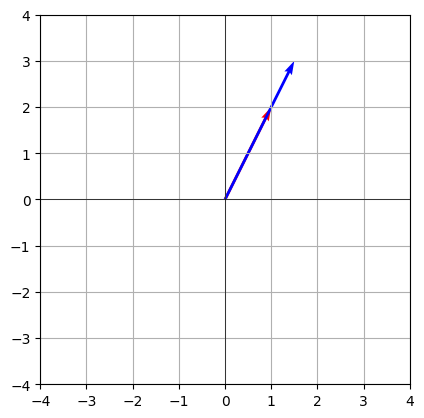

In [3]:
v1 = np.array([1, 2])
print(1.5*v1)
plot_vector([v1, 1.5 * v1])



**Vector addition**

\begin{align}
    \vec{v_1} = \begin{bmatrix}
           1 \\
           2 \\
         \end{bmatrix} \\
         \\
    \vec{v_2} = \begin{bmatrix}
           -2 \\
           1 \\
         \end{bmatrix}
    \\
    \\
    \vec{v_1} + \vec{v_2} = \begin{bmatrix}
        -1 \\
        3 \\
      \end{bmatrix}
\end{align}


[-1  3]


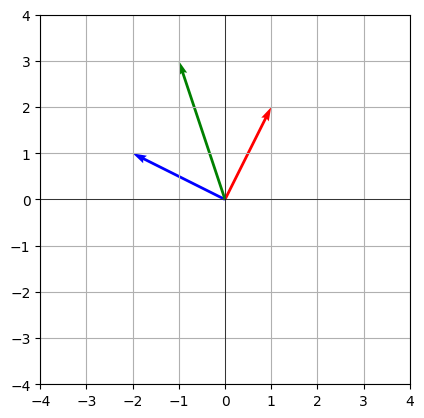

In [4]:
v1 = np.array([1, 2])
v2 = np.array([-2, 1])
print(v1 + v2)
plot_vector([v1, v2, v1 + v2])

**Linear Combinations**
* Use addition and scalar multiplication together, we can fill the plane. Combining points on the two lines defined by the vectors gives all the points.
\begin{align}
    \vec{v} = \begin{bmatrix}
           v1 \\
           v1 \\
         \end{bmatrix} \\
         \\
    \vec{u} = \begin{bmatrix}
           u1 \\
           u2 \\
         \end{bmatrix}
    \\
    \\
    a * \vec{v_1} + b * \vec{v_2} = \begin{bmatrix}
        a*u1 \\
        b*u2 \\
      \end{bmatrix}
\end{align}

#### **What is a basis?**

When a list of vectors span a space, we call them a basis of the space.

1. **Span:** their linear combinations can reach every vector in the space.
2. **Linear independence:** none of the basis vectors can be made by combining the others.

For the 2D plane, a basis consists of two nonzero vectors that do not lie along the same line. The simplest choice is the **standard basis**:

$$
\vec{v}=\begin{bmatrix}1\\0\end{bmatrix},
\qquad
\vec{u}_2=\begin{bmatrix}0\\1\end{bmatrix}.
$$

For example,

$$
\begin{bmatrix}3\\2\end{bmatrix}
=3\vec{v}+2\vec{u}.
$$

The numbers 3 and 2 are the **coordinates relative to this basis**: they tell us how much of each building block to use.

A basis does **not** have to consist of perpendicular or unit-length vectors.

But the vectors need to be linearly independent, $[1,0]$ and $[2,0]$ do **not** form a basis of the plane: the second is twice the first, so their combinations only reach the horizontal axis.


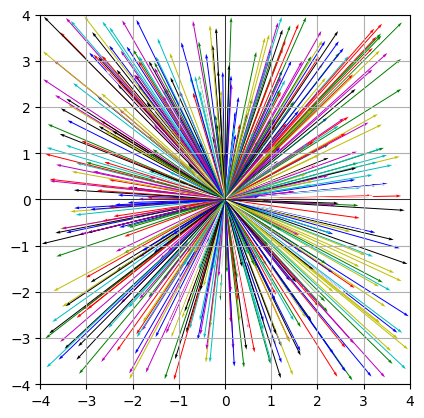

In [5]:
v1 = np.array([1, 0])
v2 = np.array([0, 1])
linear_combinations = [v1, v2]
for i in range(500):
    random_scalar_1 = np.random.uniform(-4, 4)
    random_scalar_2 = np.random.uniform(-4, 4)
    linear_combinations.append(random_scalar_1 * v1 + random_scalar_2 * v2)
plot_vector(linear_combinations)

### **Dot Product**

Dot product multiplies the first component v1 u1, and the second component v2 u2, and so on.

$$
\vec{v}\cdot\vec{u}=\vec{v}^{\mathsf T}\vec{u}
=\sum_{i=1}^{n}v_i u_i
=v_1u_1+v_2u_2+\cdots+v_nu_n.
$$

For example, if $\vec{v}=[3,2]$ and $\vec{u}=[4,1]$, then

$$
\vec{v}\cdot\vec{u}=3\times4+2\times1=14.
$$

#### **Dot product as projection**

For two nonzero vectors, the same dot product can be written as

$$
\vec{v}\cdot\vec{u}=\|\vec{v}\|\,\|\vec{u}\|\cos\theta,
$$

where $\|\vec{v}\|$ is the length of $\vec{v}$ and $\theta$ is the angle between the vectors.

Imagine dropping a perpendicular from the tip of $\vec{v}$ onto the line through $\vec{u}$. This gives the **projection** of $\vec{v}$ onto that line.

* **dot product = signed scalar projection onto the direction of $\vec{u}$ times the length of $\vec{u}$**.
* When both $\vec{u}$ and \vect{v} are unit vectors, the dot product is $\cos\theta$.
* Dot product is zero for two perpendicular vectors.


In the plot below, the green arrow is the vector projection. The dashed segment meets the projection line at a right angle.


Dot product: 14
Vector projection: [3.29411765 0.82352941]


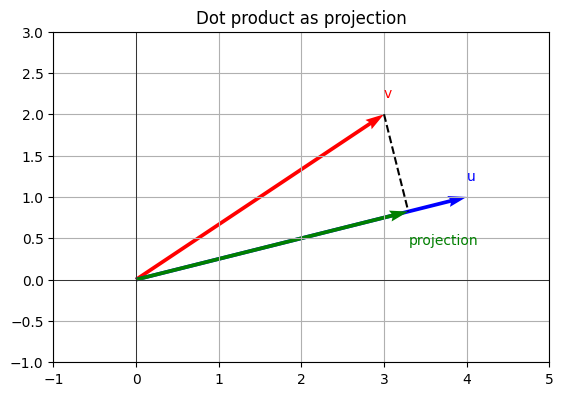

In [6]:
v = np.array([3, 2])
u = np.array([4, 1])

# Project v onto the direction of u.
dot_product = v @ u
projection = (dot_product / (u @ u)) * u
print("Dot product:", dot_product)
print("Vector projection:", projection)

plot_vector([v, u, projection])  # Red: v, blue: u, green: projection
plt.plot([v[0], projection[0]], [v[1], projection[1]], 'k--')
plt.text(v[0], v[1] + 0.2, 'v', color='r')
plt.text(u[0], u[1] + 0.2, 'u', color='b')
plt.text(projection[0], projection[1] - 0.4, 'projection', color='g')
plt.xlim(-1, 5)
plt.ylim(-1, 3)
plt.title('Dot product as projection')
plt.show()


### **Matrices**

Matrices are rectangular array of numbers.

\begin{align}
  M = \begin{bmatrix}
           m_{11} & m_{12} & m_{13} & ... & m_{1m} \\
           m_{21} & m_{22} & m_{23} & ... & m_{2m}\\
           \vdots & \vdots & \vdots & \vdots & \vdots\\
           m_{n1} & m_{n2} & m_{n3} & ... & m_{nm}
         \end{bmatrix}
  \text{is a } n \times m \text{ matrix} \\
\text{}
\end{align}

For example,
\begin{align}
  M = \begin{bmatrix}
           1 & 2 & 1 \\
           3 & 4 & 7 \\
           2 & 6 & 3 \\
           5 & 8 & 2 \\
         \end{bmatrix}
\text{is a } 4 \times 3 \text{ matrix} \\
\end{align}

**Matrix-Vector Multiplication $A\vec{v}$**

Matrix-vector multiplication follows the form:

$$
\underbrace{\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix}}_{A\; (m\times n)}
\underbrace{\begin{bmatrix}
v_1 \\ v_2 \\ \vdots \\ v_n
\end{bmatrix}}_{v\; (n\times 1)}
=
\underbrace{\begin{bmatrix}
a_{11}v_1+a_{12}v_2+\cdots+a_{1n}v_n \\
a_{21}v_1+a_{22}v_2+\cdots+a_{2n}v_n \\
\vdots \\
a_{m1}v_1+a_{m2}v_2+\cdots+a_{mn}v_n
\end{bmatrix}}_{Av\; (m\times 1)}.
$$

* Each entry of the output is the **dot product of one row of $A$ with $\vec{v}$**.
* The number of columns in $A$ must equal the number of entries in $\vec{v}$.

For example:

$$
\begin{bmatrix}2 & 1 \\ 0 & 1\end{bmatrix}
\begin{bmatrix}3 \\ 2\end{bmatrix}
=
\begin{bmatrix}2\times3+1\times2 \\ 0\times3+1\times2\end{bmatrix}
=
\begin{bmatrix}8 \\ 2\end{bmatrix}.
$$




**How do we interpret matrix multiplication?**
* **Row picture**: dot product of a vector $\vec{v}$ with each rows of matrix $A$.

$$
A\vec{v}
=\begin{bmatrix}a_{11}&a_{12}\\a_{21}&a_{22}\end{bmatrix}
\begin{bmatrix}v_1\\v_2\end{bmatrix}
=\begin{bmatrix}a_{11}v_1+a_{12}v_2\\a_{21}v_1+a_{22}v_2\end{bmatrix}.
$$

* **Column picture**: A linear combination of the columns of $A$.

$$
A\vec{v}
=\begin{bmatrix}a_{11}&a_{12}\\a_{21}&a_{22}\end{bmatrix}
\begin{bmatrix}v_1\\v_2\end{bmatrix}
=v_1\begin{bmatrix}a_{11}\\a_{21}\end{bmatrix}
+v_2\begin{bmatrix}a_{12}\\a_{22}\end{bmatrix}.
$$


For assignment 1, we are mostly using the row picture since we are interested in how similar two vectors are. We are using matrix multiplication as a way to calculate similarity in parallel.

Result of A @ v:
 [3.5 3. ]


Text(3.5, 3.2, 'Av')

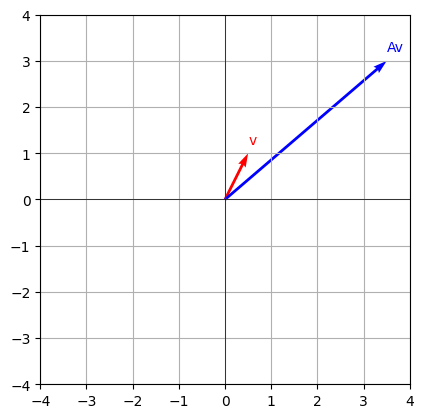

In [7]:
# Matrix multiplication in numpy
A = np.array([[1, 3], [2, 2]])
v = np.array([0.5, 1])

result = A @ v
print("Result of A @ v:\n", result)
plot_vector([v, result])  # Red: v, blue: result
plt.text(v[0], v[1] + 0.2, 'v', color='r')
plt.text(result[0], result[1] + 0.2, 'Av', color='b')

## **Eigenvectors**

* **Eigenvectors** are nonzero vectors that don't change direction when multiplied by $A$.
* They only change by a scalar when multiplied by $A$.
* The scalars that multiply the eigenvectors are called **eigenvalue**.

$A\vec{v} = \lambda\vec{v}$

$\lambda$ is an eigenvalue of A and $\vec{v}$ is an eigenvector of A.


[1.  0.5] [2.  2.5]
[ 3. -1.] [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


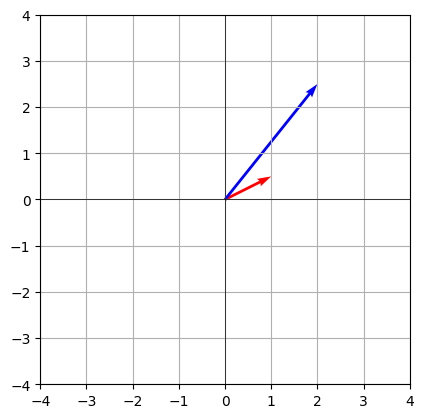

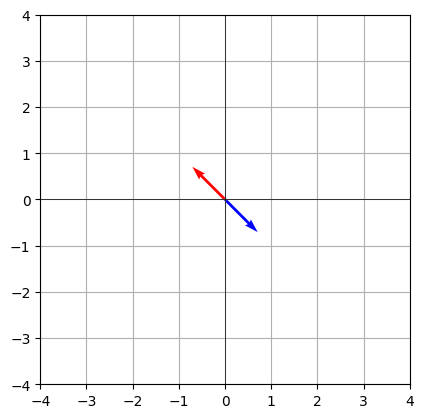

In [8]:
Mat = np.array([[1, 2], [2, 1]])

v1 = np.array([1, 0.5])
print(v1, v1.dot(Mat))
plot_vector([v1, v1.dot(Mat)])

eigenvalues, eigenvectors = np.linalg.eig(Mat)
print(eigenvalues, eigenvectors)
plot_vector([eigenvectors[:, 1], eigenvectors[:, 1].dot(Mat)])



## **PCA**



### Watermelon Analogy for PCA 🍉

Each melon has 3 measurable cues that we can observe:

- **Shape**: how round/plump it looks  
- **Color**: how yellow on the belly / less green overall  
- **Sound**: how “hollow” it sounds when you tap it  

---

There’s an **unknown hidden factor** behind these cues: **sweetness**.  

- We cannot measure sweetness directly from appearance or sound.  
- Instead, we notice that **rounder, yellower, and more hollow-sounding melons** often come together — the cues are **correlated**.  

---

**PCA** does *not* know what sweetness is.  
What it does is find **new axes** in the observed data that explain the most variance.  

- **PC1**: If sweetness drives most of the shared variation, then the first principal component will look like a **weighted combination** of shape, color, and sound that *best captures their common trend*.  

- **PC2**: A second principal component must be **orthogonal to PC1**, capturing variation that is independent of sweetness.  
  - For example, some melons might be equally “sweet-like” according to PC1, but differ in **size vs. density**.  
  - PC2 could then separate *large, hollow melons* from *small, dense melons*.  

---

Each watermelon can be described as a **weighted sum of PCs**

So PCA doesn’t tell us “how sweet” a melon is directly — instead, it gives us new axes (PCs) that summarize the patterns of variation in the observed cues.  


### PCA with IRIS Dataset

More specifically, PCA is finding the **eigenvectors** of the **covariance** matrix of a dataset. The eigenvectors capture the directions in which the data varies around its mean.
 Here we will go over the process of PCA using the IRIS dataset.

In [9]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->', linewidth=2,
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

In [10]:
iris = load_iris()
X = iris.data
y = iris.target
print("Shape of the Iris dataset:", X.shape)
print("Feature names:", iris.feature_names)

Shape of the Iris dataset: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


* For one feature column, **variance** of a feature measures how the values spread around the mean.

$\operatorname{Var}(x)
=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2$

* The **covariance** matrix represent how the features vary together. For example, for two features L and W:

$C=
\begin{bmatrix}
\operatorname{Var}(L)&\operatorname{Cov}(L,W)\\
\operatorname{Cov}(W,L)&\operatorname{Var}(W)
\end{bmatrix}$

* We need to center the data before computing the covariance matrix because we are measuring the cahnges around the mean.

In [11]:
X_petal = X[:, 2:4]
X_centered = X_petal - np.mean(X_petal, axis=0)

variance = np.var(X_petal, axis=0)
print("Variance:", variance)

covariance = X_centered.T @ X_centered / (len(X_centered)-1)
print("Covariance matrix:\n", covariance)

# cov function from numpy autocatically centers the data
np_covariance = np.cov(X_petal, rowvar=False)
print("Numpy covariance: \n", np_covariance)


Variance: [3.09550267 0.57713289]
Covariance matrix:
 [[3.11627785 1.2956094 ]
 [1.2956094  0.58100626]]
Numpy covariance: 
 [[3.11627785 1.2956094 ]
 [1.2956094  0.58100626]]


* With the covariance matrix, we then ask the question: which direction represent the greatest change?
* To find the direction with the greatest change, we find the eigenvector with the maximum eigenvalue.
* We will not try to prove this in this book, but the eigenvalue of a eigenvector of a covariance matrix is the variance of the data along the direction of the eigenvector.

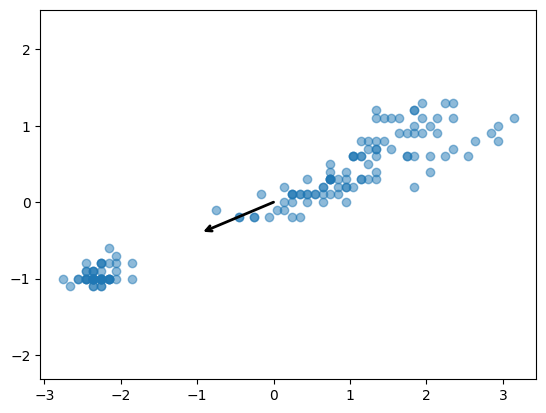

In [12]:
# Get eigenvalues and eigenvectors of covariance matrix.
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# The eigenvectors are the principle components.
# Eigenvector with the largest eigenvalue is the direction of maximum variance.
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]
# Projection score on the first PC.
scores = X_centered @ pc1
# The projected vector loses the component perpendicular to PC.
reconstructed = scores[:, None] * pc1

ax = plt.subplot()
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5)
center = X_centered.mean(axis=0)

draw_vector(center, center+pc1, ax)
plt.axis('equal')
plt.show()

* By projecting to PC1, we reduce the dimensionality of the data from 2 to 1.
* This is useful when you try to find directions of trend from noisy high dimension data.

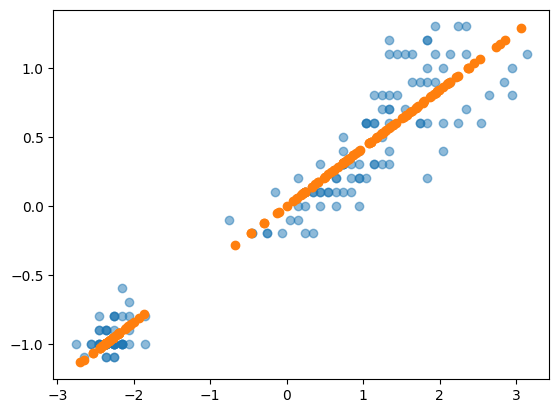

In [13]:

ax = plt.subplot()
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5)
plt.scatter(reconstructed[:, 0], reconstructed[:, 1])
plt.show()

**PCA in sklearn**
* Sklearn automatically handles centering, creating the covariance matrix and finding the eigenvectors.
* We just need to pass the data to PCA from sklearn.

original shape:    (150, 4)
transformed shape: (150, 4)


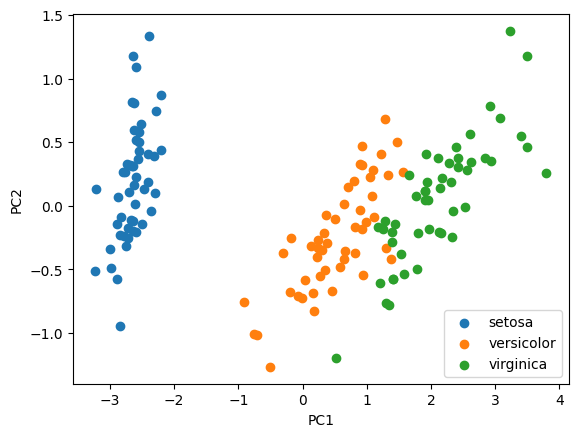

In [14]:
from sklearn.decomposition import PCA

# Specify how many PCs we want. Maximum number of PC is min(num_samples, num_features)-1
pca = PCA(n_components=4)
# We are using all four features here
pca.fit(X)
X_pca = pca.transform(X)
print("original shape:   ", X.shape)
print("transformed shape:", X_pca.shape)

# Plot the scores using the first two PCs
ax = plt.subplot()
for i, name in enumerate(iris.target_names):
  bool_mask = y == i
  ax.scatter(X_pca[bool_mask][:, 0], X_pca[bool_mask][:, 1], label=iris.target_names[i])
  ax.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Naming the axis: PC1 is highly correlated with the species label**

In [15]:
# Measure correlation between PC1 scores and species label

from scipy.stats import spearmanr

corr = spearmanr(y, X_pca[:, 0])
print(f"rho={round(corr.correlation, 4)}, p-value={corr.pvalue}")

rho=0.9298, p-value=3.9387638613660654e-66


**Explained Variance Ratio**

* The four iris features allow us to have a total of four PCs, each of them capturing an amount of variance in the data. Recall from earlier that the **eigenvalues** represent the variance along the eigenvector.
* The explained variance ratio expresses variance expaliend by one PC as a fraction of the total variance.
$$
\text{Explained variance ratio of PC}_i
=\frac{\lambda_i}{\lambda_1+\lambda_2+\lambda_3+\lambda_4}.
$$
* All the PCs together will retain 100% of the variance, but we are often interested in the number of PCs needed to explain a certain percentage of variance because we want to represent the data with fewer number of dimensions while keeping the useful information.

In [16]:
# Finding the number of PCs needed to explain 85% of variance
ratios = pca.explained_variance_ratio_
cumsum = np.cumsum(ratios)
num = np.searchsorted(cumsum, 0.85) + 1
print("Variance ratio:", ratios.round(3))
print("Cumulative:", cumsum.round(3))
print("Num needed to reach 85%:", num)

Variance ratio: [0.925 0.053 0.017 0.005]
Cumulative: [0.925 0.978 0.995 1.   ]
Num needed to reach 85%: 1


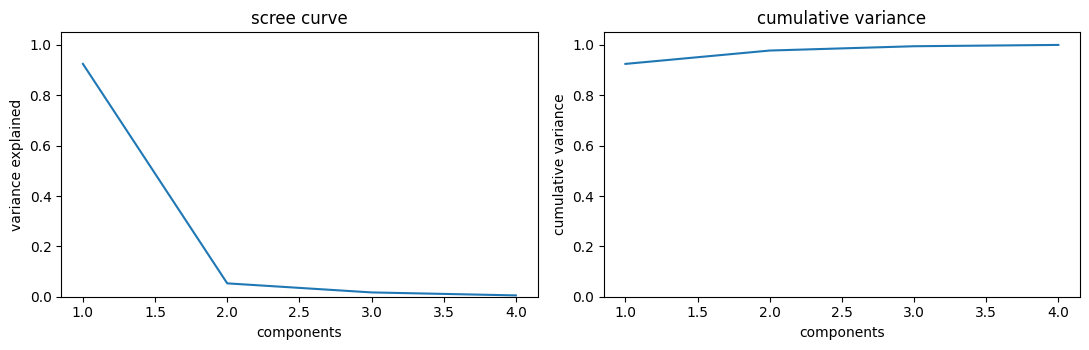

In [17]:
# The scree curve: amount of variance explained by each component
# Cumulative variance curve: how many components are needed to reach 85% of explained variance.
_, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(np.arange(1, len(cumsum)+ 1), ratios)
ax[0].set_xlabel('components')
ax[0].set_ylabel('variance explained')
ax[0].set_title('scree curve')
ax[0].set_ylim(0, 1.05)
ax[1].plot(np.arange(1, len(cumsum)+1), cumsum)
ax[1].set_xlabel('components')
ax[1].set_ylabel('cumulative variance')
ax[1].set_title('cumulative variance')
ax[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### **t-SNE in sklearn**

t-SNE is another method for dimension reduction. In t-SNE we are trying to visualize high dimensional data by fitting a lower dimension embedding. Starting from a similarity matrix, t-SNE fits a two-dimensional map in which the new points' similarities match those in the similarity matrix.

Steps of t-SNE:
1. Compute similarity of different flowers using the vectors containing the four features.
2. Initialize one point for each flower in the data.
3. Repeatedly adjust the points' location so that the similarities in the map match the similarity computed from the data.

In other words: t-SNE tries to maintain local neighbors in the data points.

We won't go over the details of the t-SNE algorithm and will just show the syntax in sklearn.

In [18]:
from sklearn.manifold import TSNE

X = iris.data
y = iris.target

tsne = TSNE(
    n_components=2, # Number of dimensions we want
    perplexity=50, # Controls the neighborhood size. You will be asked what this parameter changes the result part 4 of assignment 1
    init="pca", # Optional, initialize the points from PCA embeddings instead of random initilization to make the fit more stable
)

X_tsne = tsne.fit_transform(X)
print("Before transform shape:", X.shape)
print("After transform shape:", X_tsne.shape)

Before transform shape: (150, 4)
After transform shape: (150, 2)


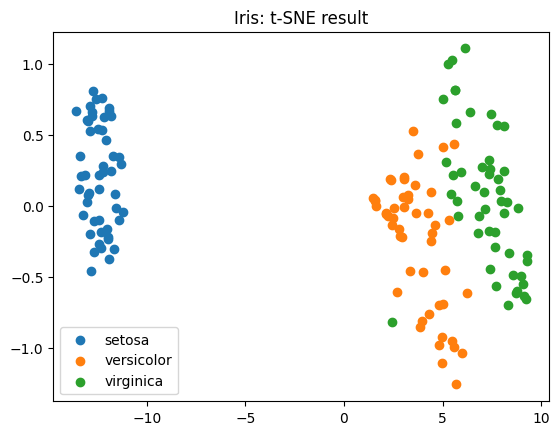

In [19]:
for i, name in enumerate(iris.target_names):
  bool_mask = y==i
  plt.scatter(
      X_tsne[bool_mask, 0],
      X_tsne[bool_mask, 1],
      label=name
  )
plt.title("Iris: t-SNE result")
plt.legend()
plt.show()


### **Curve fitting and $R^2$**
In part 2 of assignment 1, you are asked to fit a curve and compare the goodness of fit. By fitting different curves to a dataset, we are trying to find the curve that best summarize the relationship between two variables.

In python, curve fitting is done with `curve_fit` from `scipy`. We can also fit polynomials or lines with `numpy`'s `polyfit`.

In [20]:
# Simulate data and add random noise
rng = np.random.default_rng(0)
x = np.linspace(0, 5, 100)
y_true = 3 * np.exp(-0.8*x) + 2
y = y_true + rng.normal(0, 0.15, size=x.size)

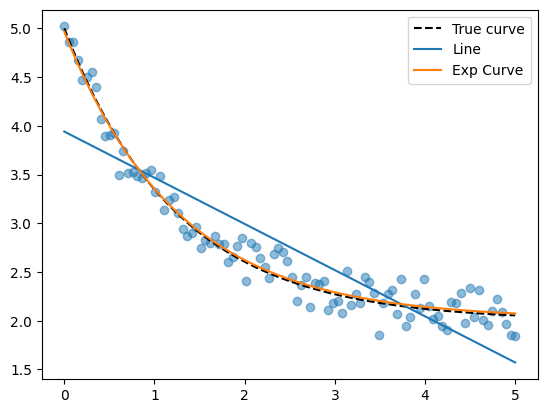

In [21]:
from scipy.optimize import curve_fit
# Fit a linear line using numpy's polyfit
params_line = np.polyfit(x, y, 1) # input, output, degree of the polynomial (1=line)
# Fit a exponential curve with curve_fit
# First we need to define the function we want to fit
def exponential(x, a, b, c):
  return a * np.exp(-b * x) + c

# Curve fit will estimate parameters a, b, c from the noisy y.
params_exp, _ = curve_fit(exponential, x, y) # model function, input, output

# Visualize the fitted line and curve
x_line = np.linspace(x.min(), x.max(), 200)

# np.polyval for predicting with the line we fitted
line_predictions = np.polyval(params_line, x_line)

# use our function for predicting with the curve
exp_predictions = exponential(x_line, params_exp[0], params_exp[1], params_exp[2])
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_true, "k--", label="True curve")
plt.plot(x_line, line_predictions, label="Line")
plt.plot(x_line, exp_predictions, label="Exp Curve")
plt.legend()
plt.show()

**Comparing the goodness of fit with $R^2$**
We can see from the visualization that the exponential curve is a much better fit than the line, but how do we express that as a number?

$R^2$ represents the percent of variance in the data explained by a model. It does this by comparing the fitted curve's squared error against simply predicting the mean for every point:

$$
R^2
=1-\frac{\sum_i(y_i-\hat{y}_i)^2}
{\sum_i(y_i-\bar{y})^2}.
$$

In [22]:
# Same function as provided in part 2 of the assignment
def r2(observed, predicted):
    """Returns one float: the fraction of the variance in observed that predicted explains."""
    residual = np.sum((observed - predicted) ** 2)
    total = np.sum((observed - observed.mean()) ** 2)
    return 1 - residual / total

line_predictions = np.polyval(params_line, x)

exp_predictions = exponential(x, params_exp[0], params_exp[1], params_exp[2])
line_r2 = r2(y, line_predictions)
exp_r2 = r2(y, exp_predictions)

print("Line R2: ", line_r2)
print("Exp R2: ", exp_r2)

Line R2:  0.7878936066927504
Exp R2:  0.9659005863046775


### **Note on comparing two RDMs**
In part 2 of the assignment, you are asked to compare RDMs with correlations. One caution is that you should only use the upper triangle of the matrices because:
1. RDMs all have 0s on the diagonal
2. RDMs are symmetrical matrices so the upper and lower triangles share the same information

These two properties would boost the correlation if you use the full RDMs. A variable named `upper_idx` is created at the top of the assignment. Use it to index the RDMs when you compare them.

In [23]:
# A simple demonstration
from scipy.stats import pearsonr
# The matrices have flipped observations at [0, 1] and [1, 2]
rdm1 = np.array([
    [0, 1, 2],
    [1, 0, 3],
    [2, 3, 0]
    ])
rdm2 = np.array([
    [0, 3, 2],
    [3, 0, 1],
    [2, 1, 0]
])

upper_idx = np.triu_indices(3, 1)
upper1 = rdm1[upper_idx]
upper2 = rdm2[upper_idx]

full_corr = pearsonr(rdm1.flatten(), rdm2.flatten())
upper_corr = pearsonr(upper1, upper2)
print(f"Full RDM result: rho {full_corr.statistic.round(3)}, p-value {full_corr.pvalue}")
print(f"Upper triangle result: rho {upper_corr.statistic.round(3)}, p-value {upper_corr.pvalue}")


Full RDM result: rho 0.333, p-value 0.3807131816768634
Upper triangle result: rho -1.0, p-value 1.3415758552508146e-08
